# Pair Trading - Statistical Arbitrage

## Data Fetch

In [217]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [218]:
start_date = "2023-01-15"
end_date = '2026-03-12'
tick_wti = 'CL=F'
tick_brent = 'BZ=F'

In [219]:
df_wti = yf.download(tickers=tick_wti, start=start_date, end=end_date).interpolate(method='linear')
df_brent = yf.download(tickers=tick_brent, start=start_date, end=end_date).interpolate(method='linear')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [220]:
df_wti.head()

Price,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F
Date,,,,,
2023-01-17,80.180000,81.230003,78.529999,80.099998,312275
2023-01-18,79.480003,82.379997,78.940002,80.970001,92549
2023-01-19,80.330002,81.180000,78.129997,79.139999,58863
2023-01-20,81.309998,81.639999,79.690002,80.599998,300145
2023-01-23,81.620003,82.639999,81.050003,81.790001,297076


In [221]:
df_brent.head()

Price,Close,High,Low,Open,Volume
Ticker,BZ=F,BZ=F,BZ=F,BZ=F,BZ=F
Date,,,,,
2023-01-17,85.919998,86.820000,83.860001,85.440002,36658
2023-01-18,84.980003,87.839996,84.400002,86.720001,26461
2023-01-19,86.160004,86.849998,83.739998,84.589996,28822
2023-01-20,87.629997,87.769997,85.580002,86.360001,24374
2023-01-23,88.190002,89.099998,86.930000,87.809998,21194


Text(0.5, 1.0, 'WTI Crude Prices')

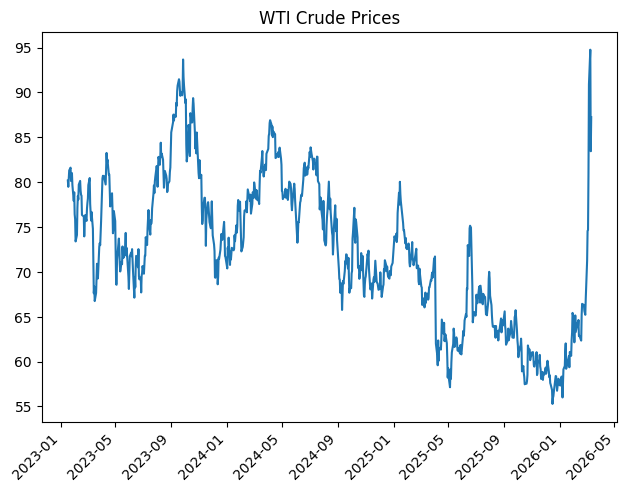

In [222]:
fig, ax = plt.subplots()
ax.plot(df_wti.Close)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.autofmt_xdate
ax.set_title('WTI Crude Prices')

Text(0.5, 1.0, 'Brent Crude Prices')

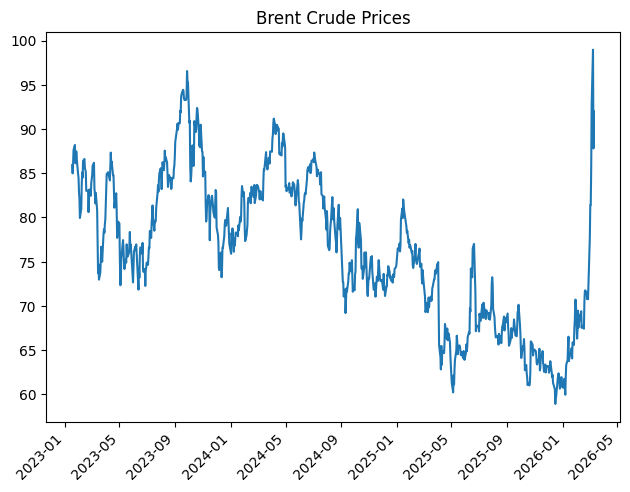

In [223]:
fig, ax = plt.subplots()
ax.plot(df_brent.Close)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.autofmt_xdate
ax.set_title('Brent Crude Prices')

In [224]:

for i in range(len(x_w)):
    if df_wti.index[i] != df_brent.index[i]:
        print(df_wti.index[i])
print(len(x_w), len(x_b))

2023-11-24 00:00:00
2023-11-27 00:00:00
2023-11-28 00:00:00
2023-11-29 00:00:00
2023-11-30 00:00:00
2023-12-01 00:00:00
2023-12-04 00:00:00
2023-12-05 00:00:00
2023-12-06 00:00:00
2023-12-07 00:00:00
2023-12-08 00:00:00
2023-12-11 00:00:00
2023-12-12 00:00:00
2023-12-13 00:00:00
2023-12-14 00:00:00
2023-12-15 00:00:00
2023-12-18 00:00:00
2023-12-19 00:00:00
2023-12-20 00:00:00
2023-12-21 00:00:00
2023-12-22 00:00:00
2023-12-26 00:00:00
2023-12-27 00:00:00
2023-12-28 00:00:00
2023-12-29 00:00:00
2024-01-02 00:00:00
2024-01-03 00:00:00
2024-01-04 00:00:00
2024-01-05 00:00:00
2024-01-08 00:00:00
2024-01-09 00:00:00
2024-01-10 00:00:00
2024-01-11 00:00:00
2024-01-12 00:00:00
2024-01-16 00:00:00
2024-01-17 00:00:00
2024-01-18 00:00:00
2024-01-19 00:00:00
2024-01-22 00:00:00
2024-01-23 00:00:00
2024-01-24 00:00:00
2024-01-25 00:00:00
2024-01-26 00:00:00
2024-01-29 00:00:00
2024-01-30 00:00:00
2024-01-31 00:00:00
2024-02-01 00:00:00
2024-02-02 00:00:00
2024-02-05 00:00:00
2024-02-06 00:00:00


In [225]:
wti_dates = set(df_wti.index)
brent_dates = set(df_brent.index)

only_in_wti = sorted(wti_dates - brent_dates)
only_in_brent = sorted(brent_dates - wti_dates)

print("Only in WTI:", only_in_wti[:20])
print("Count only in WTI:", len(only_in_wti))

print("Only in Brent:", only_in_brent[:20])
print("Count only in Brent:", len(only_in_brent))

Only in WTI: []
Count only in WTI: 0
Only in Brent: [Timestamp('2023-11-23 00:00:00')]
Count only in Brent: 1


In [226]:
from sklearn.model_selection import train_test_split
common_dates = df_wti.index.intersection(df_brent.index)

df_wti = df_wti.loc[common_dates].sort_index()
df_brent = df_brent.loc[common_dates].sort_index()

print(len(df_wti), len(df_brent))
print((df_wti.index == df_brent.index).all())
x_w = df_wti.Close
x_b = df_brent.Close
X_train_w, X_test_w, y_train_b, y_test_b = train_test_split(x_w, x_b, test_size=0.2, train_size=0.8, shuffle=False)



792 792
True


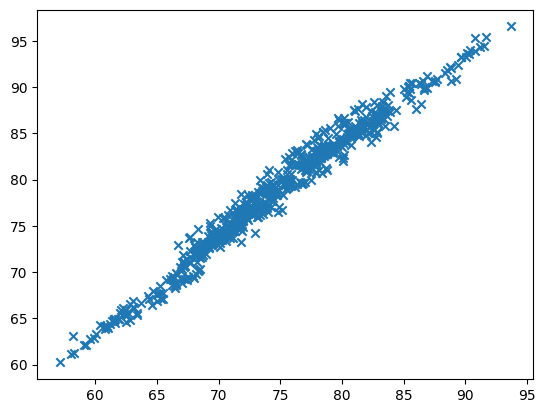

In [227]:

from statsmodels.regression.linear_model import OLS



plt.scatter(X_train_w, y_train_b, marker='x')

In [228]:
from statsmodels.api import add_constant
X_train_w = add_constant(X_train_w) 
model = OLS(y_train_b, X_train_w)
model_fit = model.fit()
model_fit.summary()





<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   BZ=F   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                 2.553e+04
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:43:00   Log-Likelihood:                -955.82
No. Observations:                 633   AIC:                             1916.
Df Residuals:                     631   BIC:                             1925.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9294      0.482      4.000      0.000       0.982       2.877
CL=F           1.0281      0.006    159.781      0.000       1.015       1.041
==============================================================================
Omnibus:                       10.032   Durbin-Watson:                   0.136
Prob(Omnibus):                  0.007   Jarque-Bera (JB):               10.136
Skew:                           0.278   Prob(JB):                      0.00630
Kurtosis:                       3.274   Cond. No.                         829.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [229]:
params = model_fit.params
print(params)

const    1.929449
CL=F     1.028121
dtype: float64


In [230]:
from sklearn.metrics import mean_squared_error
X_test_w = add_constant(X_test_w)
y_pred_b = model_fit.predict(X_test_w)

mse = mean_squared_error(y_pred_b, y_test_b)
print(mse)




0.7011866147102284


ADF Statistic : -3.5154
P-value       : 0.0076
Critical (5%) : -2.8661
Cointegrated  : YES


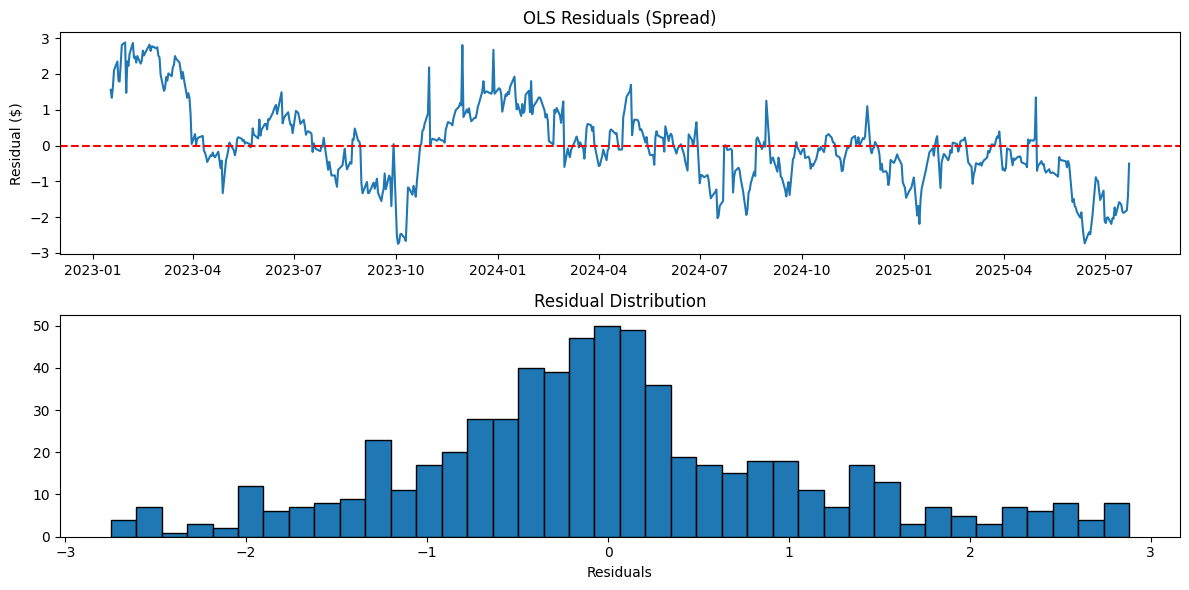

In [231]:
from statsmodels.tsa.stattools import adfuller

from statsmodels.tsa.stattools import adfuller

# Residuals from the training fit = the spread
residuals = model_fit.resid

# ADF test - null hypothesis is non-stationary (no mean reversion)
adf_result = adfuller(residuals)

print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"P-value       : {adf_result[1]:.4f}")
print(f"Critical (5%) : {adf_result[4]['5%']:.4f}")
print(f"Cointegrated  : {'YES' if adf_result[1] < 0.05 else 'NO ✗'}")

# Also plot the residuals
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(residuals.index, residuals)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('OLS Residuals (Spread)')
axes[0].set_ylabel('Residual ($)')

axes[1].hist(residuals, bins=40, edgecolor='black')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residuals')

plt.tight_layout()
plt.show()

Given that the Ridge model is finding the $\bet$a$ parameter (correlation):

\begin{equation}
Y_\text{Brent} = \alpha + \beta X_\text{WTI} + \epsilon
\end{equation}

The spread is therefore:

\begin{equation}
\text{Spread} = Y_\text{Brent} - \alpha - \beta X_\text{WTI} 
\end{equation}

We can use the training data to evaluate what is a good threshold for which the z-score should be placed for reasonable profits

In [232]:
def z_score(arr, mu, std):
    return (arr - mu) / std

In [233]:
from sklearn.linear_model import Ridge
from tqdm.auto import tqdm

window = 60
beta_roll = pd.Series(index=X_train_w.index)
lambda_roll = pd.Series(index=X_train_w.index)
z_scores = pd.Series(index=X_train_w.index)
spread = residuals
lambdas = np.logspace(-4, 4)

pbar = tqdm(range(window, len(X_train_w)))
try:
    for t in pbar:
        endog = X_train_w.iloc[t-window:t]
        exog = y_train_b.iloc[t-window:t]
        dict_params = {}
        n_folds = 3
        for lam in lambdas:
            end = int(window / 2)
            splits = 0
            lambda_mse = []
            while splits < n_folds:
                X_train_fold = endog.iloc[:end]
                y_train_fold = exog.iloc[:end]
                X_test_fold = endog.iloc[end:end+10]
                y_test_fold = exog.iloc[end:end+10]
                model = Ridge(lam)
                model_fit = model.fit(X_train_fold.values, y_train_fold.values)
                beta = model_fit.coef_[0]
                alpha = model_fit.intercept_[0]
                pars = (lam, beta, alpha)
                y_pred_fold = model_fit.predict(X_test_fold.values)
                mse_fold = mean_squared_error(y_test_fold, y_pred_fold)
                lambda_mse.append(mse_fold)
                end += 10
                splits += 1
            dict_params[pars] = np.mean(lambda_mse)

        lambda_best = None
        for key, val in dict_params.items():
            if lambda_best is None or val < lambda_best:
                lambda_best = val
                best_pars = key

        lambda_roll.iloc[t] = best_pars[0]
        spread = exog['BZ=F'] - best_pars[2] - best_pars[1] * endog['CL=F']
        mu = spread.mean()
        std = spread.std()
        z_scores.iloc[t] = z_score(spread.iloc[-1], mu, std)
finally:
    pbar.close()

















100%|██████████| 573/573 [01:51<00:00,  5.16it/s]


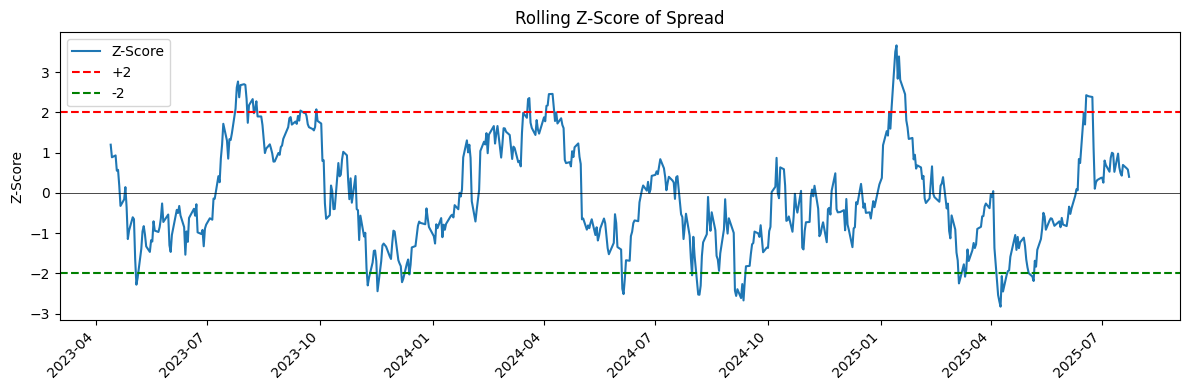

In [234]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(z_scores.dropna(), label='Z-Score')
ax.axhline(2, color='red', linestyle='--', label='+2')
ax.axhline(-2, color='green', linestyle='--', label='-2')
ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax.set_title('Rolling Z-Score of Spread')
ax.set_ylabel('Z-Score')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Total PnL   : $14.88/barrel
Sharpe Ratio: 3.97
Num trades  : 4


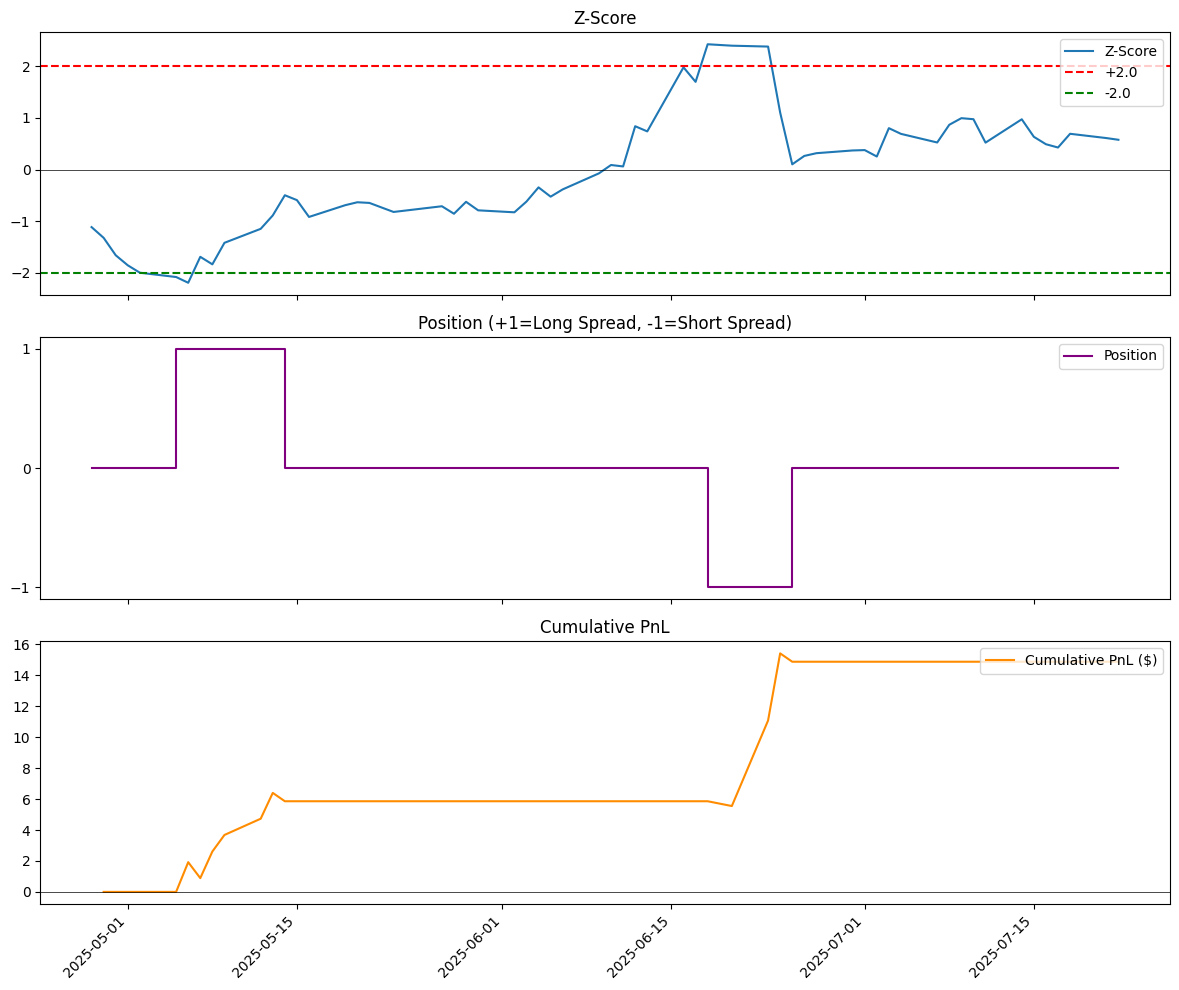

In [235]:
entry_threshold = 2.0
exit_threshold  = 0.5

common_idx = z_scores.dropna().index.intersection(spread.dropna().index)
z  = z_scores.loc[common_idx]
spread = spread.loc[common_idx]
beta   = beta_roll.loc[common_idx]


position = pd.Series(0, index=z.index, dtype=float)
current_pos = 0

for i in range(1, len(z)):
    z_val = z.iloc[i]
    if current_pos == 0:
        if z_val > entry_threshold:
            current_pos = -1
        elif z_val < -entry_threshold:
            current_pos = 1
    elif current_pos == 1 and z_val >= -exit_threshold:
        current_pos = 0
    elif current_pos == -1 and z_val <= exit_threshold:
        current_pos = 0
    position.iloc[i] = current_pos


spread_diff = spread.diff()
daily_pnl   = (position.shift(1) * spread_diff).dropna()
cum_pnl     = daily_pnl.cumsum()


n_trades = (position.diff().abs() > 0).sum()
sharpe   = daily_pnl.mean() / daily_pnl.std() * np.sqrt(252)
print(f"Total PnL   : ${cum_pnl.iloc[-1]:.2f}/barrel")
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Num trades  : {n_trades}")


fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(z, label='Z-Score')
axes[0].axhline(entry_threshold,  color='red',   linestyle='--', label=f'+{entry_threshold}')
axes[0].axhline(-entry_threshold, color='green', linestyle='--', label=f'-{entry_threshold}')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('Z-Score')
axes[0].legend(loc='upper right')

axes[1].plot(position, drawstyle='steps-post', color='purple', label='Position')
axes[1].set_title('Position (+1=Long Spread, -1=Short Spread)')
axes[1].set_yticks([-1, 0, 1])
axes[1].legend(loc='upper right')

axes[2].plot(cum_pnl, color='darkorange', label='Cumulative PnL ($)')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_title('Cumulative PnL')
axes[2].legend(loc='upper right')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The Sharpe Ratio is not indicative as this is what the training data has been trained on. Next we apply the same strategy to the test set

100%|██████████| 99/99 [00:19<00:00,  5.16it/s]


[TEST] Total PnL   : $-5.06
[TEST] Sharpe Ratio: -0.44
[TEST] Num trades  : 7


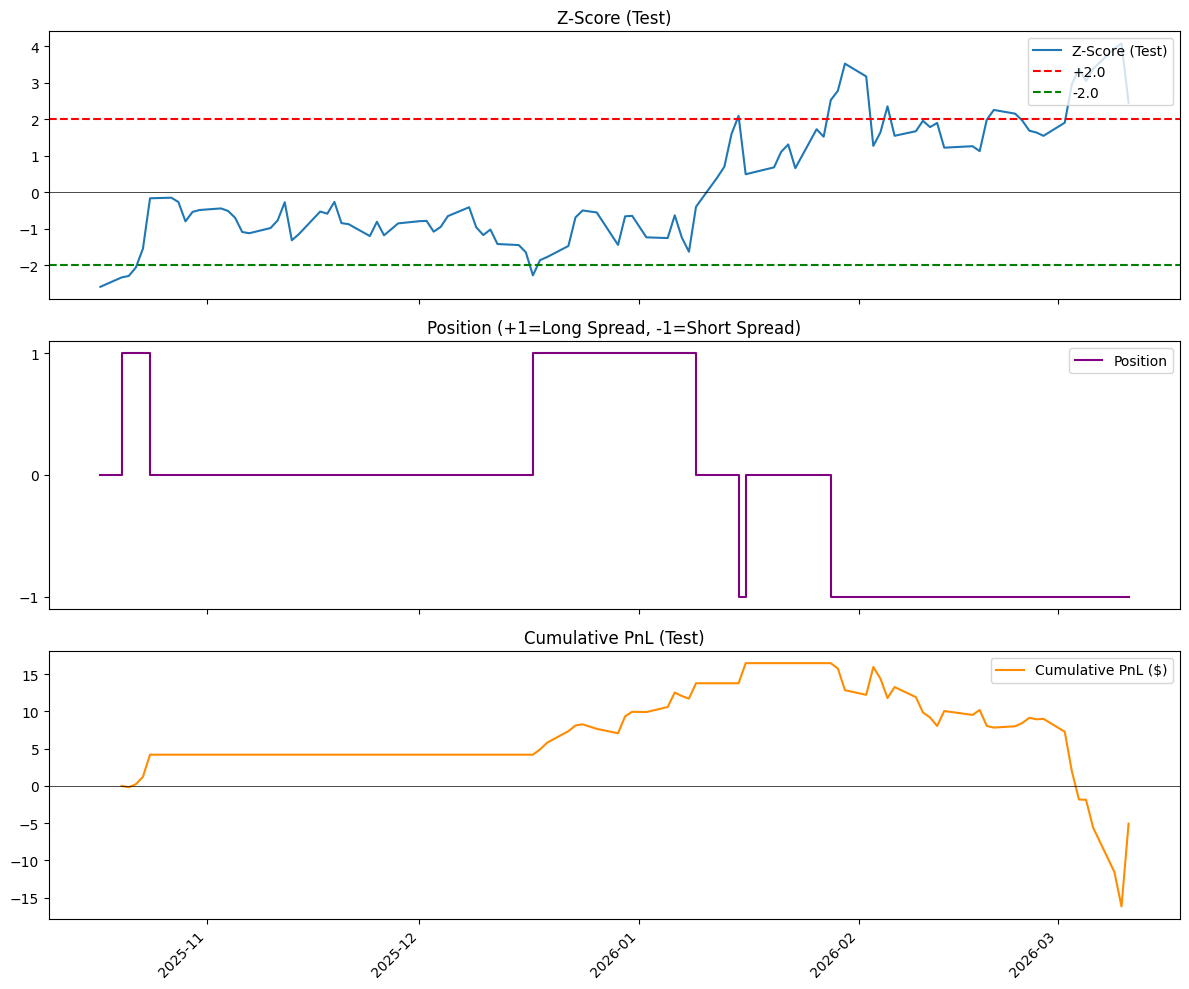

In [236]:
# --- Rolling Ridge on TEST data ---
z_scores_test  = pd.Series(index=X_test_w.index, dtype=float)
spread_roll_test = pd.Series(index=X_test_w.index, dtype=float)
lambdas = np.logspace(-4, 4)

pbar = tqdm(range(window, len(X_test_w)))
try:
    for t in pbar:
        endog = X_test_w.iloc[t-window:t]
        exog  = y_test_b.iloc[t-window:t]
        dict_params = {}
        n_folds = 3
        for lam in lambdas:
            end = int(window / 2)
            splits = 0
            lambda_mse = []
            while splits < n_folds:
                X_train_fold = endog.iloc[:end]
                y_train_fold = exog.iloc[:end]
                X_test_fold  = endog.iloc[end:end+10]
                y_test_fold  = exog.iloc[end:end+10]
                model_r = Ridge(lam)
                model_r.fit(X_train_fold.values, y_train_fold.values)
                beta  = model_r.coef_[0]
                alpha = model_r.intercept_[0]
                pars  = (lam, beta, alpha)
                y_pred_fold = model_r.predict(X_test_fold.values)
                lambda_mse.append(mean_squared_error(y_test_fold, y_pred_fold))
                end += 10
                splits += 1
            dict_params[pars] = np.mean(lambda_mse)

        lambda_best = None
        for key, val in dict_params.items():
            if lambda_best is None or val < lambda_best:
                lambda_best = val
                best_pars = key

        spread = exog['BZ=F'] - best_pars[2] - best_pars[1] * endog['CL=F']
        mu  = spread.mean()
        std = spread.std()
        z_scores_test.iloc[t]   = z_score(spread.iloc[-1], mu, std)
        spread_roll_test.iloc[t] = spread.iloc[-1]
finally:
    pbar.close()

# --- Strategy on test data ---
common_idx_test = z_scores_test.dropna().index.intersection(spread_roll_test.dropna().index)
z_test      = z_scores_test.loc[common_idx_test]
spread_test = spread_roll_test.loc[common_idx_test]

position_test = pd.Series(0, index=z_test.index, dtype=float)
current_pos = 0
for i in range(1, len(z_test)):
    z_val = z_test.iloc[i]
    if current_pos == 0:
        if z_val > entry_threshold:
            current_pos = -1
        elif z_val < -entry_threshold:
            current_pos = 1
    elif current_pos == 1 and z_val >= -exit_threshold:
        current_pos = 0
    elif current_pos == -1 and z_val <= exit_threshold:
        current_pos = 0
    position_test.iloc[i] = current_pos

daily_pnl_test = (position_test.shift(1) * spread_test.diff()).dropna()
cum_pnl_test   = daily_pnl_test.cumsum()

n_trades_test = (position_test.diff().abs() > 0).sum()
sharpe_test   = daily_pnl_test.mean() / daily_pnl_test.std() * np.sqrt(252)
print(f"[TEST] Total PnL   : ${cum_pnl_test.iloc[-1]:.2f}")
print(f"[TEST] Sharpe Ratio: {sharpe_test:.2f}")
print(f"[TEST] Num trades  : {n_trades_test}")

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(z_test, label='Z-Score (Test)')
axes[0].axhline(entry_threshold,  color='red',   linestyle='--', label=f'+{entry_threshold}')
axes[0].axhline(-entry_threshold, color='green', linestyle='--', label=f'-{entry_threshold}')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('Z-Score (Test)')
axes[0].legend(loc='upper right')

axes[1].plot(position_test, drawstyle='steps-post', color='purple', label='Position')
axes[1].set_title('Position (+1=Long Spread, -1=Short Spread)')
axes[1].set_yticks([-1, 0, 1])
axes[1].legend(loc='upper right')

axes[2].plot(cum_pnl_test, color='darkorange', label='Cumulative PnL ($)')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_title('Cumulative PnL (Test)')
axes[2].legend(loc='upper right')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The test has lost money with a negative Sharpe Ratio. The high Z-score has clearly become the norm indicating a regime change. We can filters for regimes where only mean reversion occurs

In [237]:
from sklearn.linear_model import Ridge
from tqdm.auto import tqdm
from statsmodels.tsa.stattools import adfuller

window = 60
beta_roll    = pd.Series(index=X_train_w.index, dtype=float)
lambda_roll  = pd.Series(index=X_train_w.index, dtype=float)
z_scores     = pd.Series(index=X_train_w.index, dtype=float)
spread_roll  = pd.Series(index=X_train_w.index, dtype=float)
adf_pval     = pd.Series(index=X_train_w.index, dtype=float)
lambdas = np.logspace(-4, 4)

pbar = tqdm(range(window, len(X_train_w)))
try:
    for t in pbar:
        endog = X_train_w.iloc[t-window:t]
        exog  = y_train_b.iloc[t-window:t]
        dict_params = {}
        n_folds = 3
        for lam in lambdas:
            end = int(window / 2)
            splits = 0
            lambda_mse = []
            while splits < n_folds:
                X_train_fold = endog.iloc[:end]
                y_train_fold = exog.iloc[:end]
                X_test_fold  = endog.iloc[end:end+10]
                y_test_fold  = exog.iloc[end:end+10]
                model_r = Ridge(lam)
                model_r.fit(X_train_fold.values, y_train_fold.values)
                beta  = model_r.coef_[0]
                alpha = model_r.intercept_[0]
                pars  = (lam, beta, alpha)
                y_pred_fold = model_r.predict(X_test_fold.values)
                lambda_mse.append(mean_squared_error(y_test_fold, y_pred_fold))
                end += 10
                splits += 1
            dict_params[pars] = np.mean(lambda_mse)

        lambda_best = None
        for key, val in dict_params.items():
            if lambda_best is None or val < lambda_best:
                lambda_best = val
                best_pars = key

        lambda_roll.iloc[t] = best_pars[0]
        beta_roll.iloc[t]   = best_pars[1]
        spread = exog['BZ=F'] - best_pars[2] - best_pars[1] * endog['CL=F']
        mu  = spread.mean()
        std = spread.std()
        z_scores.iloc[t]    = z_score(spread.iloc[-1], mu, std)
        spread_roll.iloc[t] = spread.iloc[-1]
        adf_pval.iloc[t]    = adfuller(spread, autolag='AIC')[1]
finally:
    pbar.close()

100%|██████████| 573/573 [01:51<00:00,  5.15it/s]


ADF p-value range: 0.0000 – 0.9988
% time p < 0.10 : 13.8%
% time p < 0.05 : 8.2%

[TRAIN] Total PnL   : $10.86
[TRAIN] Sharpe Ratio: 0.54
[TRAIN] Num trades  : 10
[TRAIN] % time in regime: 54.8%


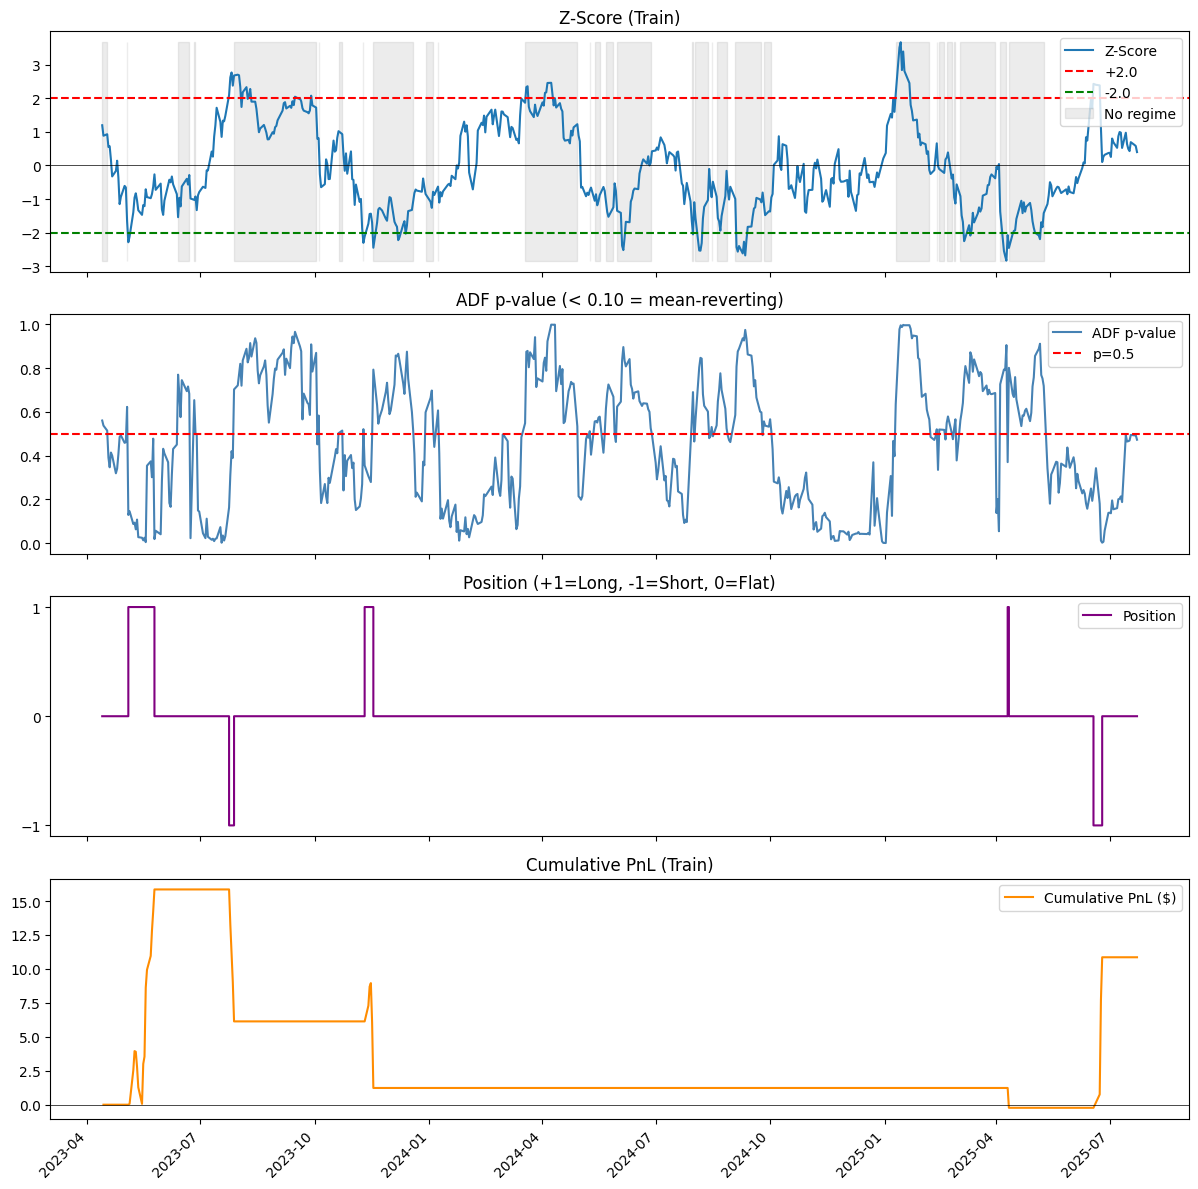

In [244]:
# Strategy parameters
entry_threshold = 2.0
exit_threshold  = 0.5
adf_threshold   = 0.50  # relaxed to 10% — ADF needs more data to reach 5% with 60-day windows

# Align on common non-null index
common_idx = z_scores.dropna().index.intersection(spread_roll.dropna().index).intersection(adf_pval.dropna().index)
z      = z_scores.loc[common_idx]
spread = spread_roll.loc[common_idx]
adf    = adf_pval.loc[common_idx]

print(f"ADF p-value range: {adf.min():.4f} – {adf.max():.4f}")
print(f"% time p < 0.10 : {(adf < 0.10).mean()*100:.1f}%")
print(f"% time p < 0.05 : {(adf < 0.05).mean()*100:.1f}%")

# --- Signal generation with regime filter ---
position = pd.Series(0, index=z.index, dtype=float)
current_pos = 0

for i in range(1, len(z)):
    z_val     = z.iloc[i]
    in_regime = adf.iloc[i] < adf_threshold

    if current_pos == 0:
        if in_regime and z_val > entry_threshold:
            current_pos = -1
        elif in_regime and z_val < -entry_threshold:
            current_pos = 1
    elif current_pos == 1 and z_val >= -exit_threshold:
        current_pos = 0
    elif current_pos == -1 and z_val <= exit_threshold:
        current_pos = 0

    if not in_regime:
        current_pos = 0

    position.iloc[i] = current_pos

# --- PnL ---
spread_diff = spread.diff()
daily_pnl   = (position.shift(1) * spread_diff).dropna()
cum_pnl     = daily_pnl.cumsum()

n_trades = (position.diff().abs() > 0).sum()
sharpe   = daily_pnl.mean() / daily_pnl.std() * np.sqrt(252)
print(f"\n[TRAIN] Total PnL   : ${cum_pnl.iloc[-1]:.2f}")
print(f"[TRAIN] Sharpe Ratio: {sharpe:.2f}")
print(f"[TRAIN] Num trades  : {n_trades}")
print(f"[TRAIN] % time in regime: {(adf < adf_threshold).mean()*100:.1f}%")

# --- Plot ---
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axes[0].plot(z, label='Z-Score')
axes[0].axhline(entry_threshold,  color='red',   linestyle='--', label=f'+{entry_threshold}')
axes[0].axhline(-entry_threshold, color='green', linestyle='--', label=f'-{entry_threshold}')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].fill_between(z.index, z.min(), z.max(), where=(adf >= adf_threshold), alpha=0.15, color='grey', label='No regime')
axes[0].set_title('Z-Score (Train)')
axes[0].legend(loc='upper right')

axes[1].plot(adf, color='steelblue', label='ADF p-value')
axes[1].axhline(adf_threshold, color='red', linestyle='--', label=f'p={adf_threshold}')
axes[1].set_title('ADF p-value (< 0.10 = mean-reverting)')
axes[1].legend(loc='upper right')

axes[2].plot(position, drawstyle='steps-post', color='purple', label='Position')
axes[2].set_title('Position (+1=Long, -1=Short, 0=Flat)')
axes[2].set_yticks([-1, 0, 1])
axes[2].legend(loc='upper right')

axes[3].plot(cum_pnl, color='darkorange', label='Cumulative PnL ($)')
axes[3].axhline(0, color='black', linewidth=0.5)
axes[3].set_title('Cumulative PnL (Train)')
axes[3].legend(loc='upper right')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

100%|██████████| 99/99 [00:28<00:00,  3.50it/s]


[TEST] Total PnL   : $1.98
[TEST] Sharpe Ratio: 1.14
[TEST] Num trades  : 4
[TEST] % time in regime: 66.7%


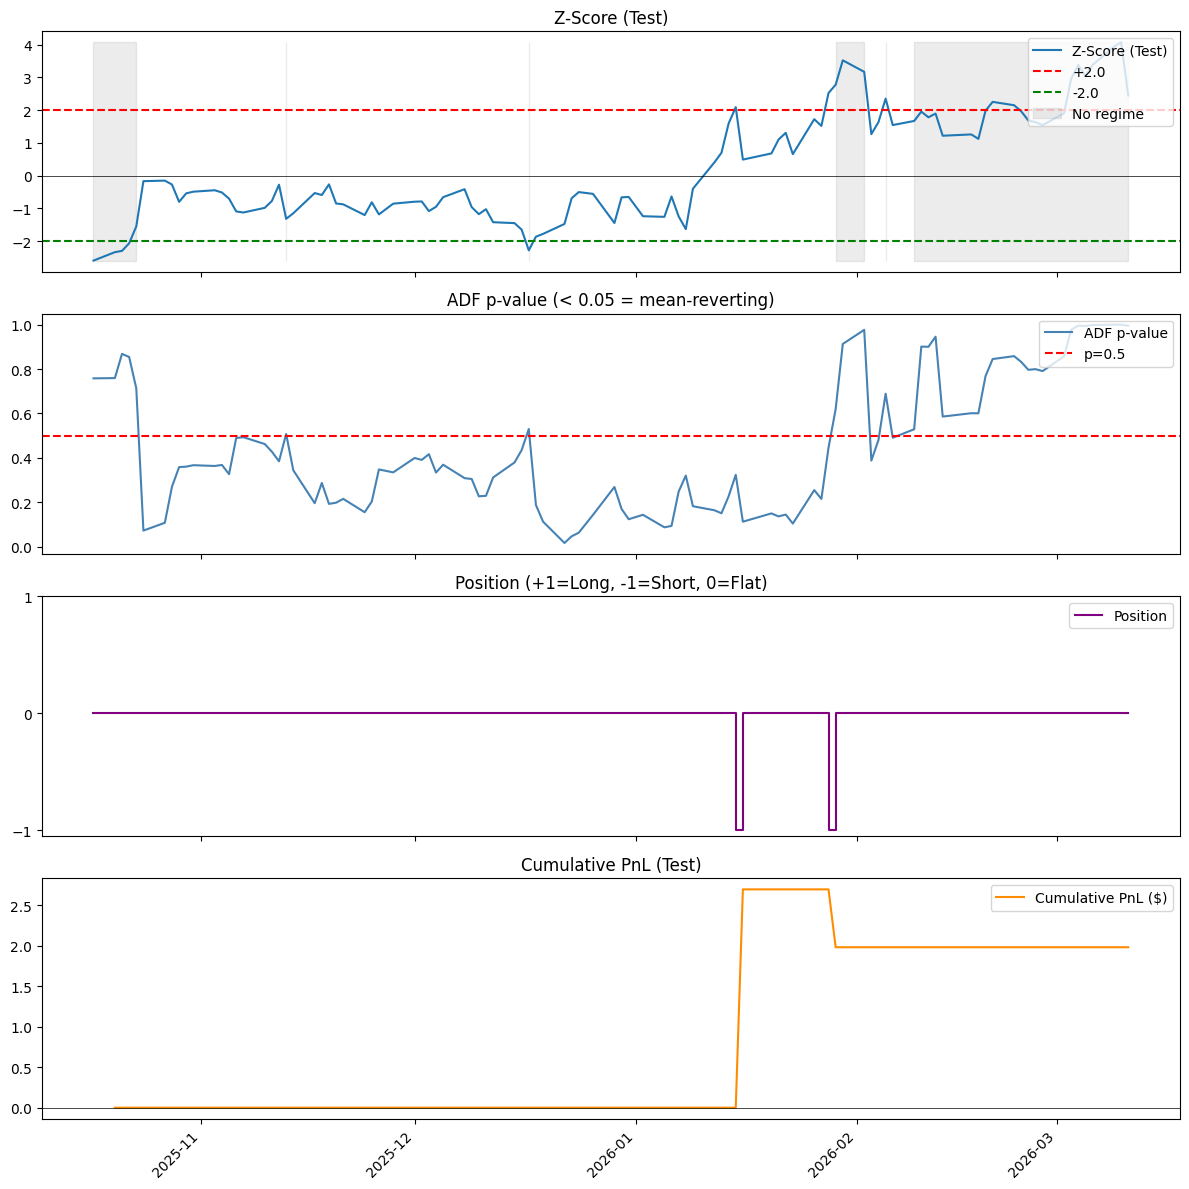

In [245]:
# --- Rolling Ridge on TEST data ---
z_scores_test    = pd.Series(index=X_test_w.index, dtype=float)
spread_roll_test = pd.Series(index=X_test_w.index, dtype=float)
adf_pval_test    = pd.Series(index=X_test_w.index, dtype=float)
lambdas = np.logspace(-4, 4)

pbar = tqdm(range(window, len(X_test_w)))
try:
    for t in pbar:
        endog = X_test_w.iloc[t-window:t]
        exog  = y_test_b.iloc[t-window:t]
        dict_params = {}
        n_folds = 3
        for lam in lambdas:
            end = int(window / 2)
            splits = 0
            lambda_mse = []
            while splits < n_folds:
                X_train_fold = endog.iloc[:end]
                y_train_fold = exog.iloc[:end]
                X_test_fold  = endog.iloc[end:end+10]
                y_test_fold  = exog.iloc[end:end+10]
                model_r = Ridge(lam)
                model_r.fit(X_train_fold.values, y_train_fold.values)
                beta  = model_r.coef_[0]
                alpha = model_r.intercept_[0]
                pars  = (lam, beta, alpha)
                y_pred_fold = model_r.predict(X_test_fold.values)
                lambda_mse.append(mean_squared_error(y_test_fold, y_pred_fold))
                end += 10
                splits += 1
            dict_params[pars] = np.mean(lambda_mse)

        lambda_best = None
        for key, val in dict_params.items():
            if lambda_best is None or val < lambda_best:
                lambda_best = val
                best_pars = key

        spread = exog['BZ=F'] - best_pars[2] - best_pars[1] * endog['CL=F']
        mu  = spread.mean()
        std = spread.std()
        z_scores_test.iloc[t]    = z_score(spread.iloc[-1], mu, std)
        spread_roll_test.iloc[t] = spread.iloc[-1]
        adf_pval_test.iloc[t]    = adfuller(spread, autolag='AIC')[1]
finally:
    pbar.close()

# --- Strategy on test data with regime filter ---
common_idx_test = (z_scores_test.dropna().index
                   .intersection(spread_roll_test.dropna().index)
                   .intersection(adf_pval_test.dropna().index))
z_test      = z_scores_test.loc[common_idx_test]
spread_test = spread_roll_test.loc[common_idx_test]
adf_test    = adf_pval_test.loc[common_idx_test]

position_test = pd.Series(0, index=z_test.index, dtype=float)
current_pos = 0
for i in range(1, len(z_test)):
    z_val     = z_test.iloc[i]
    in_regime = adf_test.iloc[i] < adf_threshold

    if current_pos == 0:
        if in_regime and z_val > entry_threshold:
            current_pos = -1
        elif in_regime and z_val < -entry_threshold:
            current_pos = 1
    elif current_pos == 1 and z_val >= -exit_threshold:
        current_pos = 0
    elif current_pos == -1 and z_val <= exit_threshold:
        current_pos = 0

    if not in_regime:
        current_pos = 0

    position_test.iloc[i] = current_pos

daily_pnl_test = (position_test.shift(1) * spread_test.diff()).dropna()
cum_pnl_test   = daily_pnl_test.cumsum()

n_trades_test = (position_test.diff().abs() > 0).sum()
sharpe_test   = daily_pnl_test.mean() / daily_pnl_test.std() * np.sqrt(252)
print(f"[TEST] Total PnL   : ${cum_pnl_test.iloc[-1]:.2f}")
print(f"[TEST] Sharpe Ratio: {sharpe_test:.2f}")
print(f"[TEST] Num trades  : {n_trades_test}")
print(f"[TEST] % time in regime: {(adf_test < adf_threshold).mean()*100:.1f}%")

# --- Plot ---
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axes[0].plot(z_test, label='Z-Score (Test)')
axes[0].axhline(entry_threshold,  color='red',   linestyle='--', label=f'+{entry_threshold}')
axes[0].axhline(-entry_threshold, color='green', linestyle='--', label=f'-{entry_threshold}')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].fill_between(z_test.index, z_test.min(), z_test.max(), where=(adf_test >= adf_threshold), alpha=0.15, color='grey', label='No regime')
axes[0].set_title('Z-Score (Test)')
axes[0].legend(loc='upper right')

axes[1].plot(adf_test, color='steelblue', label='ADF p-value')
axes[1].axhline(adf_threshold, color='red', linestyle='--', label=f'p={adf_threshold}')
axes[1].set_title('ADF p-value (< 0.05 = mean-reverting)')
axes[1].legend(loc='upper right')

axes[2].plot(position_test, drawstyle='steps-post', color='purple', label='Position')
axes[2].set_title('Position (+1=Long, -1=Short, 0=Flat)')
axes[2].set_yticks([-1, 0, 1])
axes[2].legend(loc='upper right')

axes[3].plot(cum_pnl_test, color='darkorange', label='Cumulative PnL ($)')
axes[3].axhline(0, color='black', linewidth=0.5)
axes[3].set_title('Cumulative PnL (Test)')
axes[3].legend(loc='upper right')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()